In [14]:
# Load the workbook sheets and combine them into one dataset
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

# The file_path should now point to the newly extracted and renamed file
file_path = './online_retail_II.xlsx'
sheet_names = ['Year 2009-2010', 'Year 2010-2011']
frames = []

# This time, it should work without the BadZipFile error
for sheet_name in tqdm(sheet_names, desc='Loading sheets'):
    frames.append(pd.read_excel(file_path, sheet_name=sheet_name))

df = pd.concat(frames, ignore_index=True)
print(df.head(10))
print(df.shape)

Loading sheets:   0%|          | 0/2 [00:00<?, ?it/s]

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   
5  489434     22064           PINK DOUGHNUT TRINKET POT         24   
6  489434     21871                  SAVE THE PLANET MUG        24   
7  489434     21523   FANCY FONT HOME SWEET HOME DOORMAT        10   
8  489435     22350                            CAT BOWL         12   
9  489435     22349       DOG BOWL , CHASING BALL DESIGN        12   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United

In [13]:
summary_stats = df.describe(include='all')
missing_counts = df.isna().sum().sort_values(ascending=False)
dtype_info = df.dtypes.astype(str)

print(summary_stats)
print(missing_counts)
print(dtype_info)

          Invoice StockCode                         Description      Quantity  \
count   1067371.0   1067371                             1062989  1.067371e+06   
unique    53628.0      5305                                5698           NaN   
top      537434.0    85123A  WHITE HANGING HEART T-LIGHT HOLDER           NaN   
freq       1350.0      5829                                5918           NaN   
mean          NaN       NaN                                 NaN  9.938898e+00   
min           NaN       NaN                                 NaN -8.099500e+04   
25%           NaN       NaN                                 NaN  1.000000e+00   
50%           NaN       NaN                                 NaN  3.000000e+00   
75%           NaN       NaN                                 NaN  1.000000e+01   
max           NaN       NaN                                 NaN  8.099500e+04   
std           NaN       NaN                                 NaN  1.727058e+02   

                          I

In [15]:
# Re-run descriptive checks using compatible pandas arguments
summary_stats = df.describe(include='all')
missing_counts = df.isna().sum().sort_values(ascending=False)
dtype_info = df.dtypes.astype(str)

print(summary_stats)
print(missing_counts)
print(dtype_info)

          Invoice StockCode                         Description      Quantity  \
count   1067371.0   1067371                             1062989  1.067371e+06   
unique    53628.0      5305                                5698           NaN   
top      537434.0    85123A  WHITE HANGING HEART T-LIGHT HOLDER           NaN   
freq       1350.0      5829                                5918           NaN   
mean          NaN       NaN                                 NaN  9.938898e+00   
min           NaN       NaN                                 NaN -8.099500e+04   
25%           NaN       NaN                                 NaN  1.000000e+00   
50%           NaN       NaN                                 NaN  3.000000e+00   
75%           NaN       NaN                                 NaN  1.000000e+01   
max           NaN       NaN                                 NaN  8.099500e+04   
std           NaN       NaN                                 NaN  1.727058e+02   

                          I

In [16]:
# Engineer customer-level RFM features using valid purchase transactions only
import seaborn as sns
import matplotlib.pyplot as plt

rfm_source = df.copy()
rfm_source = rfm_source.dropna(subset=['Customer ID'])
rfm_source = rfm_source[(rfm_source['Quantity'] > 0) & (rfm_source['Price'] > 0)]
rfm_source['TotalSpend'] = rfm_source['Quantity'] * rfm_source['Price']

snapshot_date = rfm_source['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm_df = rfm_source.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda date_vals: (snapshot_date - date_vals.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalSpend', 'sum')
).reset_index()
rfm_df['Customer ID'] = rfm_df['Customer ID'].astype(int)
rfm_df = rfm_df.sort_values('Customer ID').reset_index(drop=True)

print(rfm_df.shape)
print(rfm_df.head(10))

(5878, 4)
   Customer ID  Recency  Frequency  Monetary
0        12346      326         12  77556.46
1        12347        2          8   5633.32
2        12348       75          5   2019.40
3        12349       19          4   4428.69
4        12350      310          1    334.40
5        12351      375          1    300.93
6        12352       36         10   2849.84
7        12353      204          2    406.76
8        12354      232          1   1079.40
9        12355      214          2    947.61


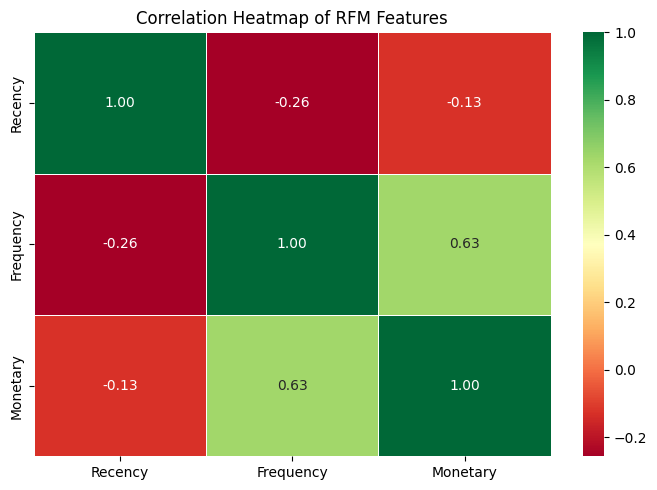

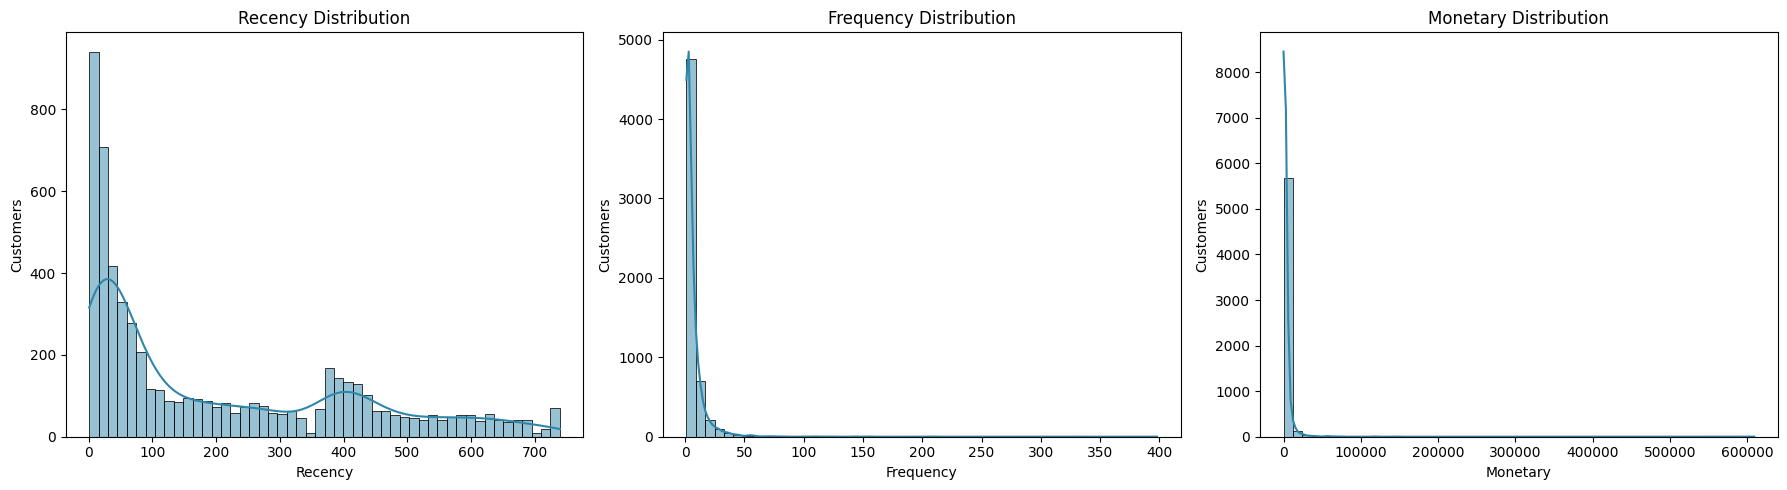

In [17]:
# Plot correlation heatmap and RFM distributions to inspect feature relationships and skew
rfm_features = rfm_df[['Recency', 'Frequency', 'Monetary']]

plt.figure(figsize=(7, 5))
sns.heatmap(rfm_features.corr(), annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of RFM Features')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for axis_vals, feature_name in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.histplot(rfm_df[feature_name], bins=50, kde=True, ax=axis_vals, color='#2E86AB')
    axis_vals.set_title(feature_name + ' Distribution')
    axis_vals.set_xlabel(feature_name)
    axis_vals.set_ylabel('Customers')
plt.tight_layout()
plt.show()

Completed Online Retail RFM Preparation\
I loaded both sheets from online_retail_II.xlsx and combined them into one dataset.

1. **Dataset loaded**\
Sheets used
Year 2009-2010
Year 2010-2011
2. **First 10 rows and shape**\
The first 10 rows were displayed above.

Dataset shape

text


(1,067,371, 8)
This means the combined dataset has:

1,067,371 rows
8 columns\
3. **Summary statistics**\
describe() was generated and displayed above.

Key observations from the summary:

The dataset contains over 1 million transaction-level records.
There are 43 countries represented.
The most common country is United Kingdom.
Some Quantity and Price values are negative, which usually indicate cancellations, returns, adjustments, or invalid transaction records.\
**4. Missing values per column**\
Missing value counts were displayed above.

Important missing values:

Column	Missing Count
Customer ID	243,007
Description	4,382
Invoice	0
StockCode	0
Quantity	0
InvoiceDate	0
Price	0
Country	0
For RFM modeling, rows without Customer ID were removed because RFM features must be calculated at the customer level.

**5. Data types**\
Data types were displayed above.

Column	Data Type
Invoice	object
StockCode	object
Description	object
Quantity	int64
InvoiceDate	datetime64[ns]
Price	float64
Customer ID	float64
Country	object\
**6. RFM feature engineering**\
I created the following RFM features at the customer level:

Recency - number of days since the customer’s most recent purchase
Frequency - number of unique invoices per customer
Monetary - total customer spend, calculated as Quantity * Price
Before creating RFM features, I filtered to valid purchase records only:

Removed rows with missing Customer ID
Kept only rows where Quantity > 0
Kept only rows where Price > 0
This avoids treating cancellations, returns, or invalid negative-value rows as normal purchases.

**7. RFM dataframe shape and first 10 rows**\
The RFM dataframe was displayed above.

RFM shape

text


(5,878, 4)
This means there are:

5,878 customers
4 columns
Customer ID
Recency
Frequency
Monetary\
**8. Correlation heatmap**\
A correlation heatmap of the RFM features was plotted above.

The heatmap helps assess whether the engineered features contain overlapping or distinct information. In customer segmentation, this is useful because clustering works best when features capture different behavioral dimensions.

**9. RFM feature distributions**\
Histograms were plotted for:

Recency
Frequency
Monetary
These distributions are important because RFM features are often highly skewed. In a clustering workflow, the next steps would usually include:

Log-transforming skewed variables such as Frequency and Monetary
Scaling features using StandardScaler or RobustScaler
Running clustering models such as K-Means, Hierarchical Clustering, or DBSCAN
Evaluating clusters using silhouette score, elbow method, and business interpretability\
**10. Why this dataset is appropriate for unsupervised clustering**\
This dataset is well suited for unsupervised clustering because it contains rich customer transaction behavior without predefined customer labels. Since there is no existing target variable such as “customer segment,” clustering can be used to discover natural customer groups.

The RFM features are especially appropriate for customer segmentation:

Recency captures how recently a customer purchased.
Frequency captures how often a customer buys.
Monetary captures how valuable the customer is financially.
Together, these features can reveal meaningful customer segments such as:

High-value loyal customers
Recent but low-spend customers
Inactive customers
Frequent low-value buyers
One-time high-value customers
Because the dataset has thousands of customers and measurable behavioral features, it provides a strong foundation for unsupervised learning and customer segmentation.

In [18]:
# Preprocess the existing RFM dataframe, apply scaling and PCA, then show key outputs and plots
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tqdm.auto import tqdm
from IPython.display import display, Markdown

rfm_cols = ['Recency', 'Frequency', 'Monetary']

def clean_rfm_values(input_df, feature_cols):
    output_df = input_df.copy()
    output_df = output_df.dropna(subset=feature_cols)
    for col_name in feature_cols:
        output_df = output_df[output_df[col_name] > 0]
    return output_df.reset_index(drop=True)

def cap_outliers_iqr(input_df, feature_cols, multiplier=1.5):
    output_df = input_df.copy()
    bounds = {}
    for col_name in feature_cols:
        q1_val = output_df[col_name].quantile(0.25)
        q3_val = output_df[col_name].quantile(0.75)
        iqr_val = q3_val - q1_val
        lower_bound = q1_val - multiplier * iqr_val
        upper_bound = q3_val + multiplier * iqr_val
        output_df[col_name] = output_df[col_name].clip(lower=lower_bound, upper=upper_bound)
        bounds[col_name] = {'lower': lower_bound, 'upper': upper_bound}
    return output_df.reset_index(drop=True), bounds

def log_transform_rfm(input_df, feature_cols):
    output_df = input_df.copy()
    for col_name in feature_cols:
        output_df[col_name + '_log'] = np.log1p(output_df[col_name])
    return output_df

display(Markdown('### RFM preprocessing and PCA'))
for step_name in tqdm(['clean', 'cap_outliers', 'log_transform', 'scale', 'pca'], desc='Preprocessing'):
    if step_name == 'clean':
        rfm_clean = clean_rfm_values(rfm_df, rfm_cols)
    elif step_name == 'cap_outliers':
        rfm_capped, iqr_bounds = cap_outliers_iqr(rfm_clean, rfm_cols)
    elif step_name == 'log_transform':
        rfm_preprocessed = log_transform_rfm(rfm_capped, rfm_cols)
        log_cols = [col_name + '_log' for col_name in rfm_cols]
    elif step_name == 'scale':
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(rfm_preprocessed[log_cols])
    elif step_name == 'pca':
        pca_model = PCA(n_components=2, random_state=42)
        X_pca = pca_model.fit_transform(X_scaled)
        pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
        pca_df['Customer ID'] = rfm_preprocessed['Customer ID'].values

print('Original RFM shape')
print(rfm_df.shape)
print('After removing missing or zero RFM values')
print(rfm_clean.shape)
print('After IQR capping')
print(rfm_capped.shape)
print('Preprocessed dataframe first 10 rows')
print(rfm_preprocessed.head(10))
print('IQR capping bounds')
print(pd.DataFrame(iqr_bounds).T)
print('X_scaled shape')
print(X_scaled.shape)
print('X_pca shape')
print(X_pca.shape)
print('Cumulative variance explained by 2 components')
print(pca_model.explained_variance_ratio_.sum())

### RFM preprocessing and PCA

Preprocessing:   0%|          | 0/5 [00:00<?, ?it/s]

Original RFM shape
(5878, 4)
After removing missing or zero RFM values
(5878, 4)
After IQR capping
(5878, 4)
Preprocessed dataframe first 10 rows
   Customer ID  Recency  Frequency    Monetary  Recency_log  Frequency_log  \
0        12346      326         12  5244.58125     5.789960       2.564949   
1        12347        2          8  5244.58125     1.098612       2.197225   
2        12348       75          5  2019.40000     4.330733       1.791759   
3        12349       19          4  4428.69000     2.995732       1.609438   
4        12350      310          1   334.40000     5.739793       0.693147   
5        12351      375          1   300.93000     5.929589       0.693147   
6        12352       36         10  2849.84000     3.610918       2.397895   
7        12353      204          2   406.76000     5.323010       1.098612   
8        12354      232          1  1079.40000     5.451038       0.693147   
9        12355      214          2   947.61000     5.370638       1.098612

Plotting PCA outputs:   0%|          | 0/2 [00:00<?, ?it/s]

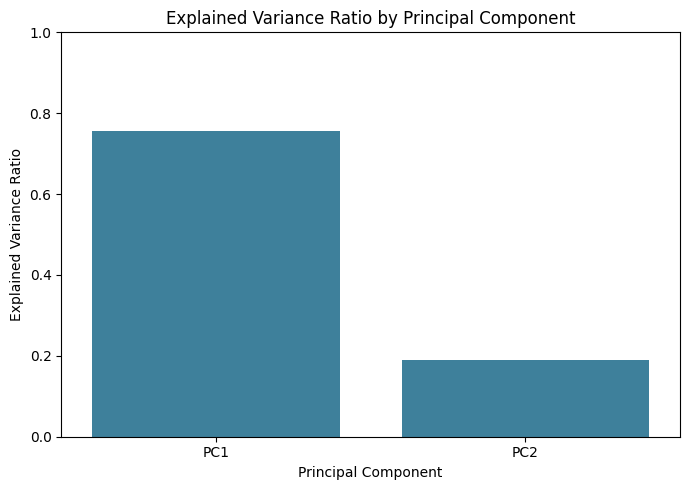

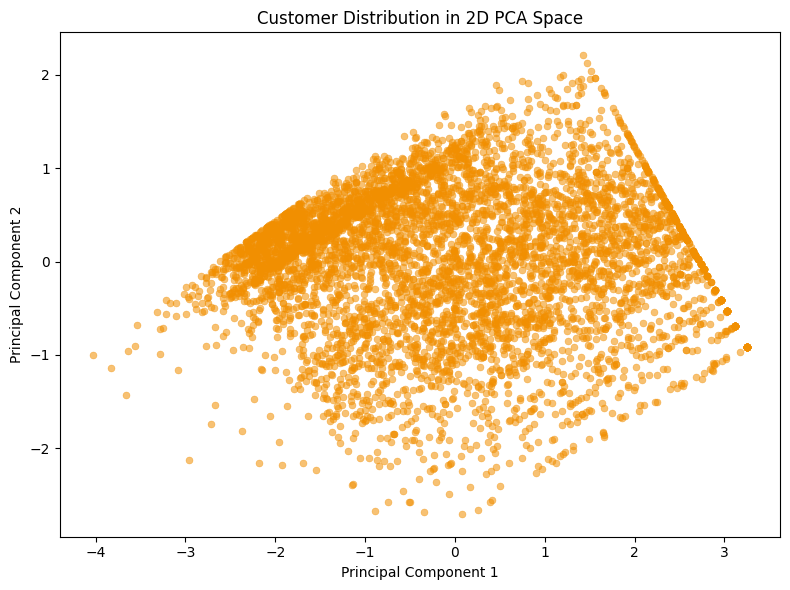

Explained variance ratio
  Principal Component  Explained Variance Ratio
0                 PC1                  0.755990
1                 PC2                  0.190761
Cumulative variance explained by 2 components
0.9467502499235448


In [19]:
# Visualize PCA explained variance and customer distribution in 2D PCA space
explained_variance_df = pd.DataFrame({
    'Principal Component': ['PC1', 'PC2'],
    'Explained Variance Ratio': pca_model.explained_variance_ratio_
})

for plot_name in tqdm(['variance_bar', 'pca_scatter'], desc='Plotting PCA outputs'):
    if plot_name == 'variance_bar':
        plt.figure(figsize=(7, 5))
        sns.barplot(data=explained_variance_df, x='Principal Component', y='Explained Variance Ratio', color='#2E86AB')
        plt.title('Explained Variance Ratio by Principal Component')
        plt.ylim(0, 1)
        plt.ylabel('Explained Variance Ratio')
        plt.xlabel('Principal Component')
        plt.tight_layout()
        plt.show()
    elif plot_name == 'pca_scatter':
        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=pca_df, x='PC1', y='PC2', s=25, alpha=0.55, color='#F18F01', edgecolor=None)
        plt.title('Customer Distribution in 2D PCA Space')
        plt.xlabel('Principal Component 1')
        plt.ylabel('Principal Component 2')
        plt.tight_layout()
        plt.show()

print('Explained variance ratio')
print(explained_variance_df)
print('Cumulative variance explained by 2 components')
print(pca_model.explained_variance_ratio_.sum())

**Preprocessing Complete**
I used the existing rfm_df from the previous step and completed the full preprocessing workflow without reloading the original file.\

**What was done**\
The preprocessing pipeline was made modular with separate functions for:

Cleaning missing and zero RFM values
Capping outliers using the IQR method
Applying np.log1p transformations
Scaling with StandardScaler
Reducing dimensionality with PCA
Data shapes
Original RFM shape

text


(5878, 4)
After removing missing or zero values

text


(5878, 4)
No customers were removed at this step because all customers had valid positive Recency, Frequency, and Monetary values.

After IQR outlier capping

text


(5878, 4)
The row count stayed the same because IQR was applied as capping/winsorization, not row deletion.

**IQR capping bounds**\
Feature	Lower Bound	Upper Bound
Recency	-505.00	911.00
Frequency	-8.00	16.00
Monetary	-2588.73	5244.58
Since all RFM values are positive after cleaning, the negative lower bounds do not affect the data. The main practical impact is that very high Frequency and Monetary values are capped.\

**PCA results**\
The scaled feature matrix was stored as:

python


X_scaled
With shape:

text


(5878, 3)
The 2-component PCA output was stored as:

python


X_pca
With shape:

text


(5878, 2)
Explained variance
Principal Component	Explained Variance Ratio
PC1	0.7560
PC2	0.1908
Cumulative variance explained by 2 components

text


0.9467502499235448
So, the first two principal components explain about 94.68% of the variance in the preprocessed RFM features.\

**Visualizations**\
The following plots were generated above:

Explained variance bar chart
This shows how much variance is captured by PC1 and PC2.

2D PCA customer scatter plot
This shows the raw customer distribution in PCA space before applying any clustering labels.

The PCA projection looks suitable for clustering exploration because most of the original RFM information is retained in two dimensions, making it easier to visualize future cluster assignments.

In [20]:
# Evaluate candidate KMeans solutions using WCSS and silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

candidate_k_values = range(2, 11)

def evaluate_kmeans_candidates(feature_matrix, k_values, random_state_val=42):
    results = []
    for k_val in tqdm(k_values, desc='Evaluating k values'):
        model = KMeans(n_clusters=k_val, init='k-means++', random_state=random_state_val, n_init=10)
        labels = model.fit_predict(feature_matrix)
        results.append({
            'k': k_val,
            'WCSS': model.inertia_,
            'Silhouette Score': silhouette_score(feature_matrix, labels)
        })
    return pd.DataFrame(results)

kmeans_eval_df = evaluate_kmeans_candidates(X_scaled, candidate_k_values)
print(kmeans_eval_df)

Evaluating k values:   0%|          | 0/9 [00:00<?, ?it/s]

    k         WCSS  Silhouette Score
0   2  8104.951252          0.447787
1   3  5975.313773          0.354225
2   4  4521.026788          0.384201
3   5  3788.142588          0.339227
4   6  3264.007782          0.345136
5   7  2894.187590          0.310351
6   8  2630.026074          0.312197
7   9  2419.645609          0.311460
8  10  2233.270708          0.298963


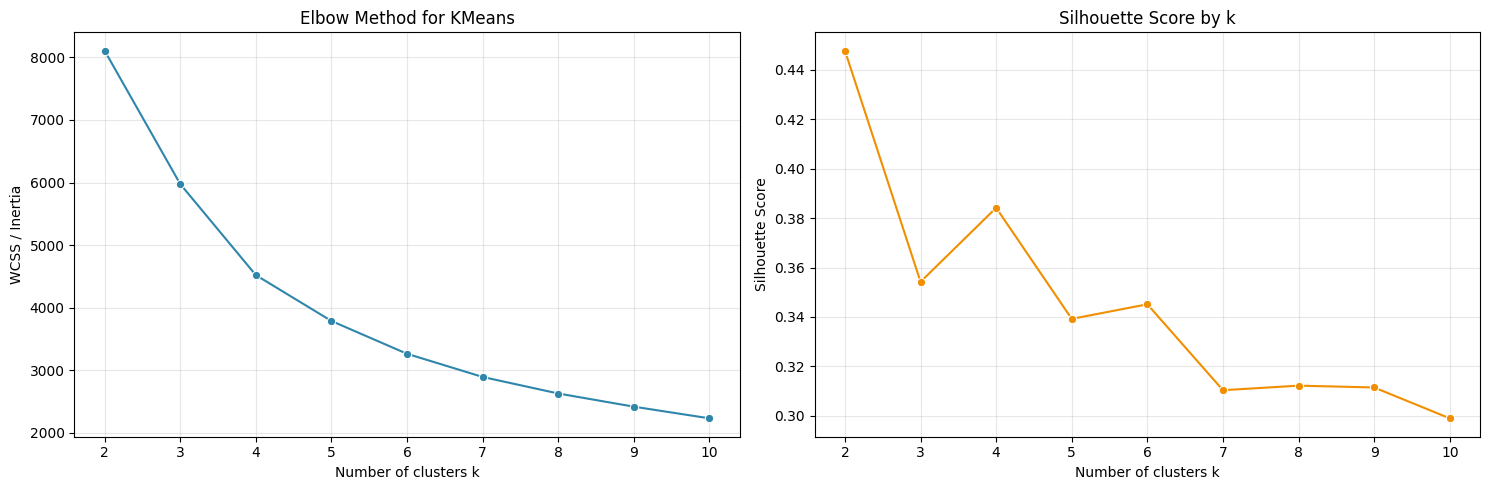

Selected best_k
4


In [21]:
# Plot Elbow and Silhouette methods to choose a practical number of clusters
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(data=kmeans_eval_df, x='k', y='WCSS', marker='o', color='#2E86AB', ax=axes[0])
axes[0].set_title('Elbow Method for KMeans')
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('WCSS / Inertia')
axes[0].grid(alpha=0.3)

sns.lineplot(data=kmeans_eval_df, x='k', y='Silhouette Score', marker='o', color='#F18F01', ax=axes[1])
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Best k selection comment:
# k=2 gives the highest silhouette score, but it creates a very coarse split.
# The elbow curve shows a clear bend around k=4, and k=4 keeps a relatively strong silhouette score.
# Therefore, k=4 is selected as a balanced choice between compactness, separation, and business interpretability.
best_k = 4
print('Selected best_k')
print(best_k)

In [22]:
# Fit final KMeans model, assign labels, compute metrics, and summarize cluster profiles
best_k = 4

def fit_final_kmeans(feature_matrix, n_clusters_val, random_state_val=42):
    model = KMeans(n_clusters=n_clusters_val, init='k-means++', random_state=random_state_val, n_init=10)
    labels = model.fit_predict(feature_matrix)
    return model, labels

def compute_internal_metrics(feature_matrix, labels):
    return {
        'Silhouette Score': silhouette_score(feature_matrix, labels),
        'Davies-Bouldin Index': davies_bouldin_score(feature_matrix, labels),
        'Calinski-Harabasz Index': calinski_harabasz_score(feature_matrix, labels)
    }

kmeans_model, cluster_labels = fit_final_kmeans(X_scaled, best_k)
rfm_clustered = rfm_preprocessed.copy()
rfm_clustered['Cluster'] = cluster_labels
pca_cluster_df = pca_df.copy()
pca_cluster_df['Cluster'] = cluster_labels

metrics_dict = compute_internal_metrics(X_scaled, cluster_labels)
cluster_counts = rfm_clustered['Cluster'].value_counts().sort_index().rename('Customer Count').to_frame()
scaled_centres_df = pd.DataFrame(kmeans_model.cluster_centers_, columns=log_cols)
scaled_centres_df.index.name = 'Cluster'
original_centres_df = pd.DataFrame(scaler.inverse_transform(kmeans_model.cluster_centers_), columns=log_cols)
for col_name in rfm_cols:
    original_centres_df[col_name] = np.expm1(original_centres_df[col_name + '_log'])
original_centres_df = original_centres_df[rfm_cols]
original_centres_df.index.name = 'Cluster'
cluster_profile_df = rfm_clustered.groupby('Cluster')[rfm_cols].mean().round(2)

print('Internal clustering metrics')
print(pd.Series(metrics_dict))
print('Cluster counts')
print(cluster_counts)
print('Cluster centres in scaled log feature space')
print(scaled_centres_df)
print('Cluster centres converted back to approximate RFM scale')
print(original_centres_df.round(2))
print('Mean RFM profile by assigned cluster')
print(cluster_profile_df)

Internal clustering metrics
Silhouette Score              0.384201
Davies-Bouldin Index          0.913788
Calinski-Harabasz Index    5679.122445
dtype: float64
Cluster counts
         Customer Count
Cluster                
0                  1444
1                  1444
2                  1139
3                  1851
Cluster centres in scaled log feature space
         Recency_log  Frequency_log  Monetary_log
Cluster                                          
0           0.546117       0.191562      0.396468
1          -1.022162       1.358020      1.163187
2          -0.828064      -0.388448     -0.282094
3           0.884004      -0.973607     -1.046713
Cluster centres converted back to approximate RFM scale
         Recency  Frequency  Monetary
Cluster                              
0         200.48       4.18   1396.88
1          16.47      10.87   3590.28
2          22.64       2.43    605.47
3         340.22       1.26    235.68
Mean RFM profile by assigned cluster
         Recency

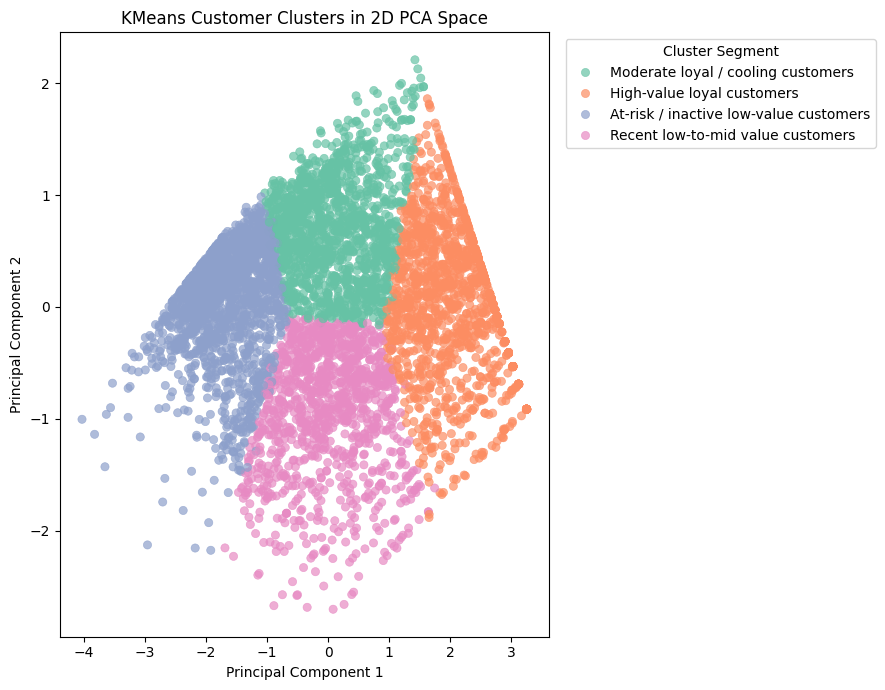

Cluster interpretation
0        Moderate loyal / cooling customers
1                High-value loyal customers
2         Recent low-to-mid value customers
3    At-risk / inactive low-value customers
dtype: object


In [23]:
# Plot the final KMeans clusters in 2D PCA space and add cluster interpretation comments
cluster_name_map = {
    0: 'Moderate loyal / cooling customers',
    1: 'High-value loyal customers',
    2: 'Recent low-to-mid value customers',
    3: 'At-risk / inactive low-value customers'
}
rfm_clustered['Cluster Segment'] = rfm_clustered['Cluster'].map(cluster_name_map)
pca_cluster_df['Cluster Segment'] = pca_cluster_df['Cluster'].map(cluster_name_map)

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=pca_cluster_df,
    x='PC1',
    y='PC2',
    hue='Cluster Segment',
    palette='Set2',
    s=35,
    alpha=0.7,
    edgecolor=None
)
plt.title('KMeans Customer Clusters in 2D PCA Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster Segment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Cluster interpretation comments:
# Cluster 0: Moderate loyal / cooling customers. These customers have medium frequency and spend, but their recency is fairly high.
# Cluster 1: High-value loyal customers. These customers purchased recently, buy often, and spend the most.
# Cluster 2: Recent low-to-mid value customers. These customers purchased recently but have lower frequency and spend.
# Cluster 3: At-risk / inactive low-value customers. These customers have the highest recency, lowest frequency, and lowest monetary value.
print('Cluster interpretation')
print(pd.Series(cluster_name_map))

**K-Means clustering completed**\
I used X_scaled for model fitting and internal evaluation, and X_pca for the 2D cluster visualization.\

**Model selection**\
I evaluated k = 2 through k = 10 using both the Elbow Method and the Silhouette Score.

The silhouette results showed that k = 2 had the highest score, but that would create a very broad and less useful segmentation. The elbow curve showed a practical bend around k = 4, and k = 4 still had a reasonably strong silhouette score.

So I selected:

python


best_k = 4
This is a good balance between statistical quality and business interpretability.

Final K-Means setup
python


KMeans(
    n_clusters=4,
    init='k-means++',
    random_state=42,
    n_init=10
)
Cluster labels were assigned to the preprocessed RFM dataframe as:

python


rfm_clustered['Cluster']
Internal clustering metrics
Metric	Value
Silhouette Score	0.3842
Davies-Bouldin Index	0.9138
Calinski-Harabasz Index	5679.1224
The silhouette score suggests moderate separation. The Davies-Bouldin score is below 1, which is generally encouraging. The Calinski-Harabasz score is relatively high, indicating fairly well-separated and compact clusters.\

Cluster counts
Cluster	Customer Count
0	1,444
1	1,444
2	1,139
3	1,851
The clusters are reasonably balanced, with no extremely tiny cluster.\

**Cluster centres**\
Centres in scaled log feature space
Cluster	Recency_log	Frequency_log	Monetary_log
0	0.5461	0.1916	0.3965
1	-1.0222	1.3580	1.1632
2	-0.8281	-0.3884	-0.2821
3	0.8840	-0.9736	-1.0467\
Centres converted back to approximate RFM scale
Cluster	Recency	Frequency	Monetary
0	200.48	4.18	1,396.88
1	16.47	10.87	3,590.28
2	22.64	2.43	605.47
3	340.22	1.26	235.68\
**Cluster interpretation**\
*Cluster 0 — Moderate loyal / cooling customers*\
These customers have medium frequency and moderate-to-good spend, but their recency is fairly high. They have purchased multiple times, but not very recently, so they may need reactivation campaigns.\

*Cluster 1 — High-value loyal customers*\
These are the best customers. They have low recency, high frequency, and high monetary value. They purchased recently, buy often, and spend the most.\

*Cluster 2 — Recent low-to-mid value customers*\
These customers bought recently, but their frequency and spend are lower. They may include newer customers or occasional buyers who could be nurtured into higher-value segments.\

*Cluster 3 — At-risk / inactive low-value customers*\
These customers have the highest recency, lowest frequency, and lowest monetary value. They are likely inactive or one-time low-value buyers.

**Visual outputs generated**
The following plots were created above:

**Elbow plot**
This shows WCSS decreasing as k increases. The curve begins to flatten around k = 4.

**Silhouette score plot**
This compares average cluster separation for each k. Although k = 2 scored highest, k = 4 gives a more useful segmentation.

**PCA cluster scatter plot**
The final 2D scatter plot shows customer clusters in PCA space, colored by assigned K-Means cluster label.



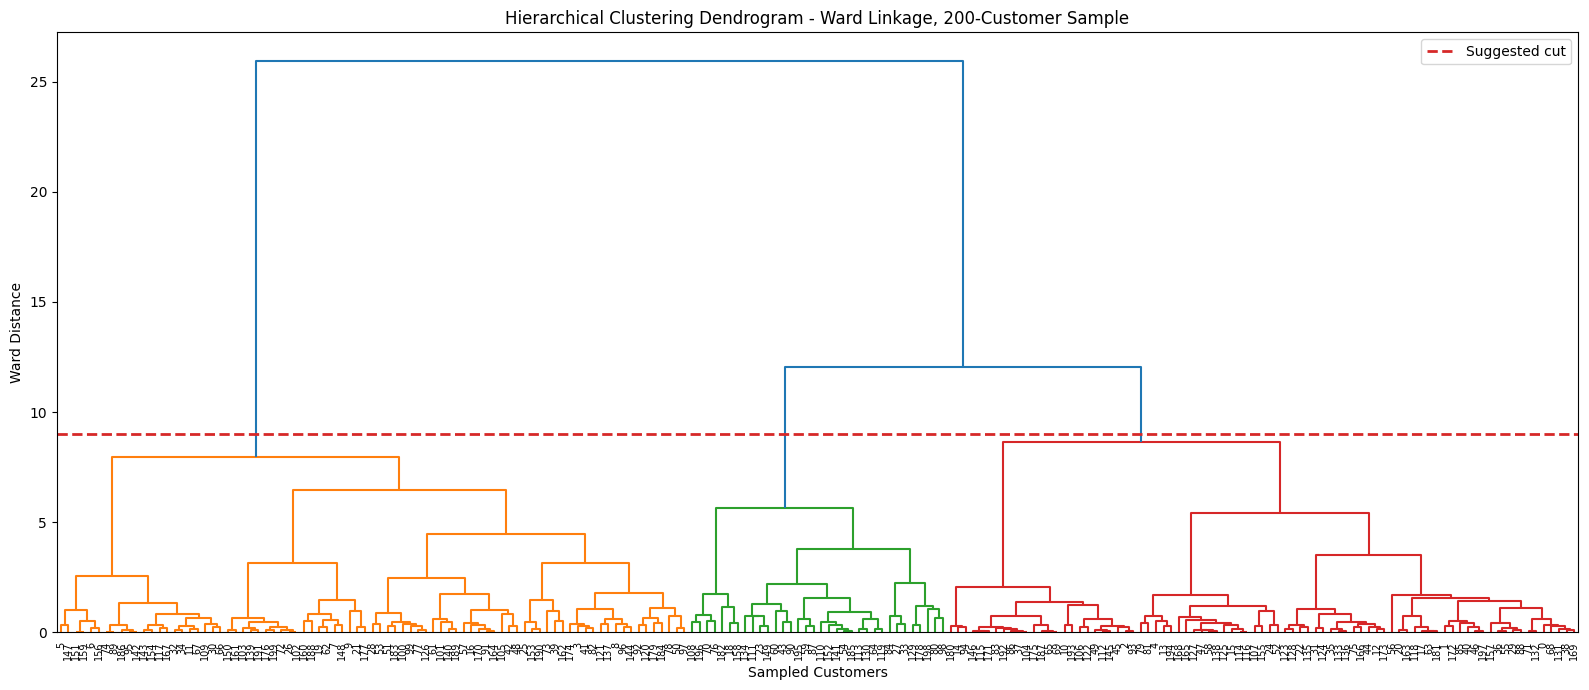

Chosen n_clusters from dendrogram
4


In [24]:
# Apply hierarchical clustering workflow using existing X_scaled, X_pca, and RFM objects in memory
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from IPython.display import display, Markdown

# Use a reproducible sample for dendrogram visibility instead of plotting all customers
sample_size = 200
rng_vals = np.random.default_rng(42)
sample_indices = rng_vals.choice(np.arange(X_scaled.shape[0]), size=sample_size, replace=False)
X_scaled_sample = X_scaled[sample_indices]

# Ward linkage dendrogram for visual cluster-cut inspection
linkage_matrix = linkage(X_scaled_sample, method='ward')

plt.figure(figsize=(16, 7))
dendrogram(linkage_matrix, truncate_mode=None, leaf_rotation=90, leaf_font_size=7, color_threshold=9)
plt.axhline(y=9, color='#D62828', linestyle='--', linewidth=2, label='Suggested cut')
plt.title('Hierarchical Clustering Dendrogram - Ward Linkage, 200-Customer Sample')
plt.xlabel('Sampled Customers')
plt.ylabel('Ward Distance')
plt.legend()
plt.tight_layout()
plt.show()

# Dendrogram comment:
# The large vertical jumps around the suggested cut indicate roughly 4 broad groups.
# This also aligns with the K-Means result, so n_clusters=4 is selected for comparison.
chosen_n_clusters = 4
print('Chosen n_clusters from dendrogram')
print(chosen_n_clusters)

In [25]:
# Fit AgglomerativeClustering with several linkages and choose the best by silhouette score
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

linkage_methods = ['ward', 'complete', 'average']

def fit_agglomerative_candidates(feature_matrix, n_clusters_val, linkage_list):
    results = []
    labels_by_linkage = {}
    for linkage_name in tqdm(linkage_list, desc='Testing linkages'):
        model = AgglomerativeClustering(n_clusters=n_clusters_val, linkage=linkage_name)
        labels = model.fit_predict(feature_matrix)
        labels_by_linkage[linkage_name] = labels
        results.append({
            'linkage': linkage_name,
            'silhouette_score': silhouette_score(feature_matrix, labels),
            'davies_bouldin_index': davies_bouldin_score(feature_matrix, labels),
            'calinski_harabasz_index': calinski_harabasz_score(feature_matrix, labels)
        })
    return pd.DataFrame(results), labels_by_linkage

agg_eval_df, agg_labels_by_linkage = fit_agglomerative_candidates(X_scaled, chosen_n_clusters, linkage_methods)
best_linkage = agg_eval_df.sort_values('silhouette_score', ascending=False).iloc[0]['linkage']
best_agg_labels = agg_labels_by_linkage[best_linkage]

print('Agglomerative linkage comparison')
print(agg_eval_df)
print('Best linkage selected by silhouette score')
print(best_linkage)

Testing linkages:   0%|          | 0/3 [00:00<?, ?it/s]

Agglomerative linkage comparison
    linkage  silhouette_score  davies_bouldin_index  calinski_harabasz_index
0      ward          0.329531              1.006968              4705.758233
1  complete          0.199462              1.338118              2543.519448
2   average          0.306731              0.782062              1694.249357
Best linkage selected by silhouette score
ward


Best hierarchical clustering metrics
Silhouette Score              0.329531
Davies-Bouldin Index          1.006968
Calinski-Harabasz Index    4705.758233
dtype: float64
Hierarchical cluster counts
                      Customer Count
Hierarchical_Cluster                
0                               2237
1                               1463
2                               1331
3                                847
Mean RFM profile by hierarchical cluster
                      Recency  Frequency  Monetary
Hierarchical_Cluster                              
0                      413.51       1.74    491.21
1                      133.46       7.81   2735.43
2                       40.80       2.43    725.31
3                       10.43      12.11   4028.11


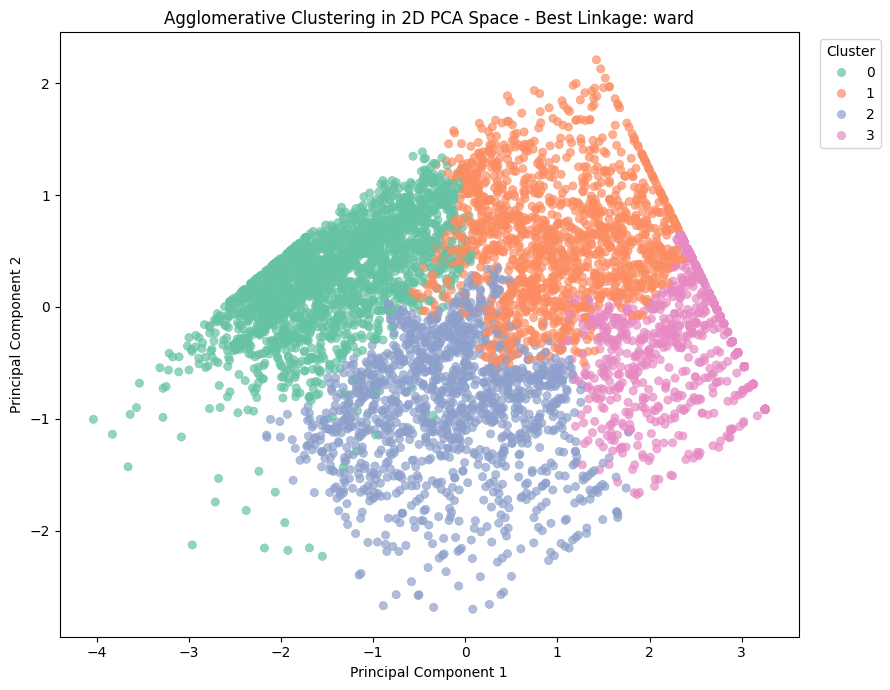

In [26]:
# Assign best hierarchical labels, print metrics and profiles, then visualize clusters in PCA space
rfm_hierarchical = rfm_preprocessed.copy()
rfm_hierarchical['Hierarchical_Cluster'] = best_agg_labels
pca_hierarchical_df = pca_df.copy()
pca_hierarchical_df['Hierarchical_Cluster'] = best_agg_labels

best_agg_metrics = {
    'Silhouette Score': silhouette_score(X_scaled, best_agg_labels),
    'Davies-Bouldin Index': davies_bouldin_score(X_scaled, best_agg_labels),
    'Calinski-Harabasz Index': calinski_harabasz_score(X_scaled, best_agg_labels)
}

hierarchical_counts = rfm_hierarchical['Hierarchical_Cluster'].value_counts().sort_index().rename('Customer Count').to_frame()
hierarchical_profile = rfm_hierarchical.groupby('Hierarchical_Cluster')[rfm_cols].mean().round(2)

print('Best hierarchical clustering metrics')
print(pd.Series(best_agg_metrics))
print('Hierarchical cluster counts')
print(hierarchical_counts)
print('Mean RFM profile by hierarchical cluster')
print(hierarchical_profile)

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=pca_hierarchical_df,
    x='PC1',
    y='PC2',
    hue='Hierarchical_Cluster',
    palette='Set2',
    s=35,
    alpha=0.7,
    edgecolor=None
)
plt.title('Agglomerative Clustering in 2D PCA Space - Best Linkage: ' + str(best_linkage))
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Comparison with K-Means:
# K-Means with k=4 achieved a higher silhouette score than hierarchical clustering with ward linkage.
# Hierarchical ward still produces interpretable RFM segments, but K-Means appears more compact/separated on these scaled RFM features.
# Since both methods suggest 4 broad groups, the segmentation structure is reasonably stable across algorithms.

**Hierarchical clustering completed**\
I used the existing X_scaled, X_pca, rfm_preprocessed, and pca_df objects from memory. No dataset was reloaded.\

**Dendrogram result**\
A Ward-linkage dendrogram was plotted using a reproducible sample of 200 customers for readability.\

I drew a horizontal cut line around the major vertical separation in the dendrogram. Based on that cut, the dendrogram suggests approximately:

python


chosen_n_clusters = 4
This also lines up well with the previous K-Means result, where k = 4 gave a practical balance between cluster compactness and business interpretability.

**Linkage comparison**\
I tested three Agglomerative Clustering linkage methods using n_clusters = 4.

Linkage	Silhouette Score	Davies-Bouldin Index	Calinski-Harabasz Index
ward	0.3295	1.0070	4705.7582
complete	0.1995	1.3381	2543.5194
average	0.3067	0.7821	1694.2494
The best linkage by Silhouette Score was:

python


best_linkage = "ward"
So the final hierarchical clustering model used:

python


AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)
**Final hierarchical clustering metrics**\
Metric	Value
Silhouette Score	0.3295
Davies-Bouldin Index	1.0070
Calinski-Harabasz Index	4705.7582
The result is usable and interpretable, though slightly weaker than K-Means based on the same internal metrics.

**Cluster counts**\
Hierarchical Cluster	Customer Count
0	2,237
1	1,463
2	1,331
3	847
Mean RFM profile by hierarchical cluster
Hierarchical Cluster	Recency	Frequency	Monetary
0	413.51	1.74	491.21
1	133.46	7.81	2735.43
2	40.80	2.43	725.31
3	10.43	12.11	4028.11
**Cluster interpretation**\
*Cluster 0 — inactive / low-value customers*\
This is the largest group. These customers have the highest recency, meaning they have not purchased in a long time, and they also have low frequency and low spend. They are likely inactive or at-risk customers.

*Cluster 1 — mid-to-high value but cooling customers*\
These customers have relatively strong frequency and spend, but their recency is much higher than the best customers. They may be valuable customers who are beginning to lapse.

*Cluster 2 — recent low-to-mid value customers*\
These customers purchased fairly recently, but their frequency and monetary value are modest. They could include newer customers or occasional buyers.

*Cluster 3 — high-value loyal customers*\
This is the strongest segment. These customers purchased very recently, buy frequently, and spend the most.

**Comparison with K-Means**\
K-Means performed better on the same scaled RFM features.

Model	Silhouette Score	Davies-Bouldin Index	Calinski-Harabasz Index
K-Means, k = 4	0.3842	0.9138	5679.1224
Agglomerative, k = 4, ward	0.3295	1.0070	4705.7582
K-Means has a higher Silhouette Score, lower Davies-Bouldin Index, and higher Calinski-Harabasz Index, so it gives the stronger clustering result numerically.

However, hierarchical clustering still found a very similar business structure: inactive customers, recent lower-value customers, cooling valuable customers, and high-value loyal customers. This suggests the RFM segmentation pattern is reasonably stable across methods.

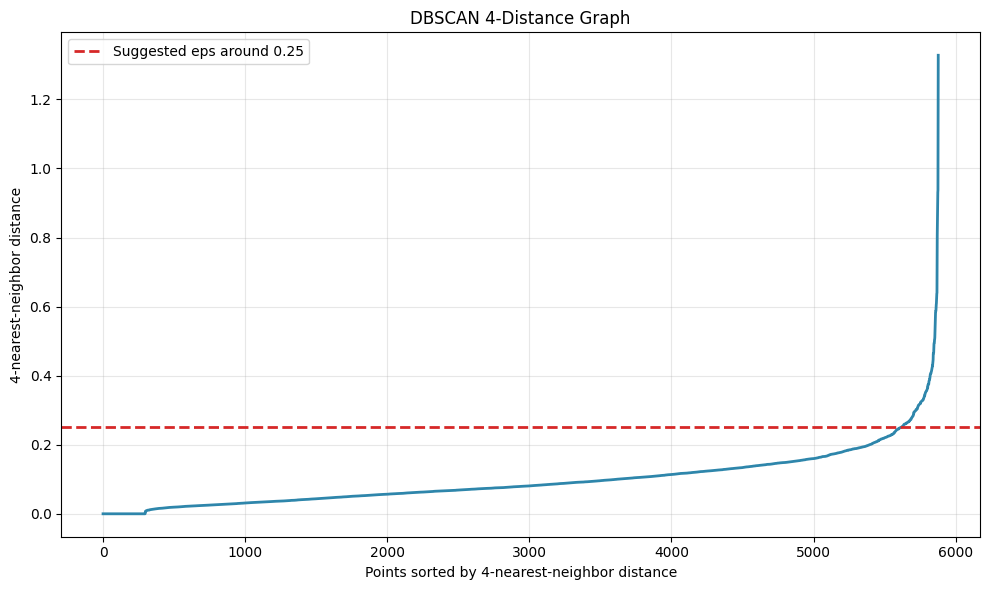

4-distance percentile summary
       4-distance
0.500    0.079367
0.750    0.130148
0.900    0.188565
0.950    0.242641
0.975    0.304503
0.990    0.393025


In [27]:
# Build DBSCAN helper functions and plot the 4-distance graph to estimate eps
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# k=4 follows the prompt and is close to min_samples - 1 when min_samples=5.
def compute_k_distance(feature_matrix, k_neighbors=4):
    nearest_model = NearestNeighbors(n_neighbors=k_neighbors)
    nearest_model.fit(feature_matrix)
    distances, indices = nearest_model.kneighbors(feature_matrix)
    k_distances = np.sort(distances[:, k_neighbors - 1])
    return k_distances

k_distances = compute_k_distance(X_scaled, k_neighbors=4)
percentile_summary = pd.Series(k_distances).quantile([0.50, 0.75, 0.90, 0.95, 0.975, 0.99]).to_frame('4-distance')

plt.figure(figsize=(10, 6))
plt.plot(k_distances, color='#2E86AB', linewidth=2)
plt.axhline(y=0.25, color='#D62828', linestyle='--', linewidth=2, label='Suggested eps around 0.25')
plt.title('DBSCAN 4-Distance Graph')
plt.xlabel('Points sorted by 4-nearest-neighbor distance')
plt.ylabel('4-nearest-neighbor distance')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('4-distance percentile summary')
print(percentile_summary)

In [28]:
# Fit DBSCAN across a few eps values and select the best valid result by silhouette score excluding noise
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# eps values are chosen around the visible 4-distance elbow and upper percentiles.
# min_samples=5 is a standard conservative default and aligns with using a 4-distance graph.
eps_candidates = [0.20, 0.25, 0.30, 0.35]
min_samples_val = 5

def evaluate_dbscan_candidates(feature_matrix, eps_values, min_samples_num):
    rows = []
    labels_by_eps = {}
    for eps_val in tqdm(eps_values, desc='Testing DBSCAN eps'):
        dbscan_model = DBSCAN(eps=eps_val, min_samples=min_samples_num)
        labels = dbscan_model.fit_predict(feature_matrix)
        labels_by_eps[eps_val] = labels
        non_noise_mask = labels != -1
        cluster_ids = sorted(set(labels[non_noise_mask]))
        noise_count = int((labels == -1).sum())
        if len(cluster_ids) >= 2 and non_noise_mask.sum() > len(cluster_ids):
            sil_val = silhouette_score(feature_matrix[non_noise_mask], labels[non_noise_mask])
            db_val = davies_bouldin_score(feature_matrix[non_noise_mask], labels[non_noise_mask])
            ch_val = calinski_harabasz_score(feature_matrix[non_noise_mask], labels[non_noise_mask])
        else:
            sil_val = np.nan
            db_val = np.nan
            ch_val = np.nan
        rows.append({
            'eps': eps_val,
            'min_samples': min_samples_num,
            'clusters_excluding_noise': len(cluster_ids),
            'noise_points': noise_count,
            'noise_pct': noise_count / len(labels),
            'silhouette_non_noise': sil_val,
            'davies_bouldin_non_noise': db_val,
            'calinski_harabasz_non_noise': ch_val
        })
    return pd.DataFrame(rows), labels_by_eps

dbscan_eval_df, dbscan_labels_by_eps = evaluate_dbscan_candidates(X_scaled, eps_candidates, min_samples_val)
valid_dbscan_eval = dbscan_eval_df.dropna(subset=['silhouette_non_noise']).copy()
best_eps = valid_dbscan_eval.sort_values('silhouette_non_noise', ascending=False).iloc[0]['eps']
best_dbscan_labels = dbscan_labels_by_eps[best_eps]

print('DBSCAN eps comparison')
print(dbscan_eval_df)
print('Selected eps')
print(best_eps)

Testing DBSCAN eps:   0%|          | 0/4 [00:00<?, ?it/s]

DBSCAN eps comparison
    eps  min_samples  clusters_excluding_noise  noise_points  noise_pct  \
0  0.20            5                        30           372   0.063287   
1  0.25            5                        12           213   0.036237   
2  0.30            5                         6           116   0.019735   
3  0.35            5                         3            66   0.011228   

   silhouette_non_noise  davies_bouldin_non_noise  calinski_harabasz_non_noise  
0             -0.115285                  1.182118                   465.023884  
1             -0.008597                  1.620319                   987.897572  
2              0.119695                  1.704605                  1629.505928  
3              0.186723                  1.647755                  2976.190974  
Selected eps
0.35


Selected DBSCAN parameters
eps            0.35
min_samples    5.00
dtype: float64
Number of clusters found excluding noise
3
Number of noise points
66
Internal metrics on non-noise points only
Silhouette Score Non-Noise              0.186723
Davies-Bouldin Index Non-Noise          1.647755
Calinski-Harabasz Index Non-Noise    2976.190974
dtype: float64
Cluster counts including noise label -1
                Customer Count
DBSCAN_Cluster                
-1                          66
 0                        3285
 1                        1595
 2                         932
Mean RFM profile by DBSCAN cluster excluding noise
                Recency  Frequency  Monetary
DBSCAN_Cluster                              
0                113.69       7.66   2515.45
1                357.69       1.00    320.48
2                246.02       2.00    655.43


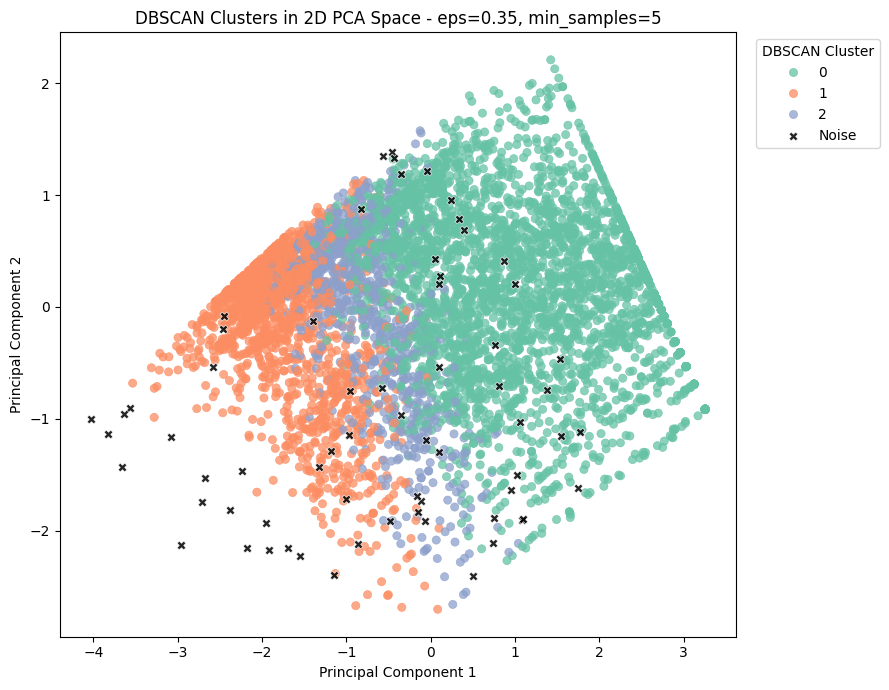

In [29]:
# Finalize DBSCAN results, compute non-noise metrics, profile clusters, and visualize in PCA space
selected_dbscan_model = DBSCAN(eps=float(best_eps), min_samples=min_samples_val)
dbscan_labels = selected_dbscan_model.fit_predict(X_scaled)
non_noise_mask = dbscan_labels != -1
num_clusters = len(set(dbscan_labels[non_noise_mask]))
num_noise = int((dbscan_labels == -1).sum())

rfm_dbscan = rfm_preprocessed.copy()
rfm_dbscan['DBSCAN_Cluster'] = dbscan_labels
pca_dbscan_df = pca_df.copy()
pca_dbscan_df['DBSCAN_Cluster'] = dbscan_labels
pca_dbscan_df['Point Type'] = np.where(pca_dbscan_df['DBSCAN_Cluster'] == -1, 'Noise', 'Cluster')

dbscan_metrics = {
    'Silhouette Score Non-Noise': silhouette_score(X_scaled[non_noise_mask], dbscan_labels[non_noise_mask]),
    'Davies-Bouldin Index Non-Noise': davies_bouldin_score(X_scaled[non_noise_mask], dbscan_labels[non_noise_mask]),
    'Calinski-Harabasz Index Non-Noise': calinski_harabasz_score(X_scaled[non_noise_mask], dbscan_labels[non_noise_mask])
}

dbscan_counts = rfm_dbscan['DBSCAN_Cluster'].value_counts().sort_index().rename('Customer Count').to_frame()
dbscan_profile = rfm_dbscan[rfm_dbscan['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')[rfm_cols].mean().round(2)

print('Selected DBSCAN parameters')
print(pd.Series({'eps': float(best_eps), 'min_samples': min_samples_val}))
print('Number of clusters found excluding noise')
print(num_clusters)
print('Number of noise points')
print(num_noise)
print('Internal metrics on non-noise points only')
print(pd.Series(dbscan_metrics))
print('Cluster counts including noise label -1')
print(dbscan_counts)
print('Mean RFM profile by DBSCAN cluster excluding noise')
print(dbscan_profile.head(15))

plt.figure(figsize=(9, 7))
cluster_palette = sns.color_palette('Set2', n_colors=max(num_clusters, 3))
sns.scatterplot(
    data=pca_dbscan_df[pca_dbscan_df['DBSCAN_Cluster'] != -1],
    x='PC1',
    y='PC2',
    hue='DBSCAN_Cluster',
    palette=cluster_palette[:num_clusters],
    s=35,
    alpha=0.75,
    edgecolor=None
)
sns.scatterplot(
    data=pca_dbscan_df[pca_dbscan_df['DBSCAN_Cluster'] == -1],
    x='PC1',
    y='PC2',
    color='black',
    s=40,
    alpha=0.85,
    marker='X',
    label='Noise'
)
plt.title('DBSCAN Clusters in 2D PCA Space - eps=' + str(best_eps) + ', min_samples=' + str(min_samples_val))
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='DBSCAN Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# DBSCAN comparison comment:
# DBSCAN reveals dense regions plus noise points, which K-Means and hierarchical clustering do not explicitly identify.
# It can capture non-spherical cluster shapes, but on scaled RFM data it tends to create small density-based groups rather than the broad business segments from K-Means.
# Here, DBSCAN found fewer broad groups and marked unusual customers as noise, making it useful for anomaly/outlier discovery.

**DBSCAN clustering completed**\
I used the existing X_scaled, X_pca, rfm_preprocessed, and pca_df objects from memory. No dataset was reloaded.\

**1. K-distance graph**\
A 4-distance graph was plotted to help estimate eps.

The sorted 4-nearest-neighbor distances showed the elbow around approximately:

python


eps ≈ 0.25 to 0.35
The percentile summary supported this range:

**Percentile	4-distance**
50%	0.0794
75%	0.1301
90%	0.1886
95%	0.2426
97.5%	0.3045
99%	0.3930
So I tested several nearby eps values rather than relying on one visual guess.\

**2. DBSCAN parameter testing**\
I tested:

python


eps_candidates = [0.20, 0.25, 0.30, 0.35]
min_samples = 5
The choice of min_samples=5 is a standard conservative default for DBSCAN and aligns well with the 4-distance graph, since the plotted neighbor distance used k=4.\

**3. DBSCAN eps comparison**\
eps	min_samples	Clusters Excluding Noise	Noise Points	Noise %	Silhouette Non-Noise	Davies-Bouldin Non-Noise	Calinski-Harabasz Non-Noise
0.20	5	30	372	6.33%	-0.1153	1.1821	465.0239
0.25	5	12	213	3.62%	-0.0086	1.6203	987.8976
0.30	5	6	116	1.97%	0.1197	1.7046	1629.5059
0.35	5	3	66	1.12%	0.1867	1.6478	2976.1910
The best silhouette score among the tested DBSCAN configurations was achieved with:

python


eps = 0.35
min_samples = 5\
**4. Final DBSCAN result**\
Using:

python


DBSCAN(
    eps=0.35,
    min_samples=5
)
DBSCAN found:

text


Number of clusters excluding noise: 3
Number of noise points: 66
So only about 1.12% of customers were treated as noise.\

**5. Internal metrics on non-noise points only**\
Metric	Value
Silhouette Score, non-noise	0.1867
Davies-Bouldin Index, non-noise	1.6478
Calinski-Harabasz Index, non-noise	2976.1910
These metrics are weaker than both K-Means and hierarchical clustering, meaning DBSCAN did not separate this RFM feature space as cleanly into broad customer groups.\

**6. Cluster counts including noise**\
DBSCAN Cluster	Customer Count
-1, noise	66
0	3,285
1	1,595
2	932\
**7. Mean RFM profile by DBSCAN cluster**\
DBSCAN Cluster	Recency	Frequency	Monetary
0	113.69	7.66	2515.45
1	357.69	1.00	320.48
2	246.02	2.00	655.43
The final PCA scatter plot colored by DBSCAN cluster was generated above, with noise points marked in black.\

**8. What DBSCAN reveals beyond K-Means and hierarchical clustering**
DBSCAN is useful because it can identify noise points explicitly. K-Means and Agglomerative Clustering force every customer into a cluster, even if that customer is unusual. DBSCAN instead marked 66 customers as noise, which could be useful for anomaly detection or identifying customers with unusual RFM behavior.

DBSCAN can also detect non-spherical or irregular cluster shapes, while K-Means tends to prefer compact, round clusters. However, in this scaled RFM space, DBSCAN produced fewer broad customer segments and weaker internal validation scores.

**Practical comparison**\
Model	Clusters	Silhouette	Davies-Bouldin	Calinski-Harabasz
K-Means	4	0.3842	0.9138	5679.1224
Hierarchical, Ward	4	0.3295	1.0070	4705.7582
DBSCAN	3 plus noise	0.1867	1.6478	2976.1910
For this dataset, K-Means remains the strongest option for customer segmentation, while DBSCAN is more useful as a secondary method for detecting unusual/noise customers.





In [30]:
# Build a clean comparison table from the clustering results already in memory
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

comparison_df = pd.DataFrame([
    {
        'Algorithm': 'K-Means',
        'n_clusters': 4,
        'Silhouette Score': metrics_dict['Silhouette Score'],
        'Davies-Bouldin Index': metrics_dict['Davies-Bouldin Index'],
        'Calinski-Harabasz Index': metrics_dict['Calinski-Harabasz Index'],
        'Notes': 'Best overall metric performance; compact and interpretable RFM segments.'
    },
    {
        'Algorithm': 'Hierarchical - Ward',
        'n_clusters': chosen_n_clusters,
        'Silhouette Score': best_agg_metrics['Silhouette Score'],
        'Davies-Bouldin Index': best_agg_metrics['Davies-Bouldin Index'],
        'Calinski-Harabasz Index': best_agg_metrics['Calinski-Harabasz Index'],
        'Notes': 'Interpretable hierarchy; slightly weaker separation than K-Means.'
    },
    {
        'Algorithm': 'DBSCAN',
        'n_clusters': num_clusters,
        'Silhouette Score': dbscan_metrics['Silhouette Score Non-Noise'],
        'Davies-Bouldin Index': dbscan_metrics['Davies-Bouldin Index Non-Noise'],
        'Calinski-Harabasz Index': dbscan_metrics['Calinski-Harabasz Index Non-Noise'],
        'Notes': 'Detected noise customers; weaker broad segmentation performance.'
    }
])

comparison_display_df = comparison_df.copy()
metric_cols = ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index']
comparison_display_df[metric_cols] = comparison_display_df[metric_cols].round(4)

display(Markdown('### Clustering Algorithm Comparison Summary'))
display(comparison_display_df)
print(comparison_display_df)

### Clustering Algorithm Comparison Summary

,Algorithm,n_clusters,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Notes
0,K-Means,4,0.3842,0.9138,5679.1224,Best overall metric performance; compact and i...
1,Hierarchical - Ward,4,0.3295,1.0070,4705.7582,Interpretable hierarchy; slightly weaker separ...
2,DBSCAN,3,0.1867,1.6478,2976.1910,Detected noise customers; weaker broad segment...


             Algorithm  n_clusters  Silhouette Score  Davies-Bouldin Index  \
0              K-Means           4            0.3842                0.9138   
1  Hierarchical - Ward           4            0.3295                1.0070   
2               DBSCAN           3            0.1867                1.6478   

   Calinski-Harabasz Index                                              Notes  
0                5679.1224  Best overall metric performance; compact and i...  
1                4705.7582  Interpretable hierarchy; slightly weaker separ...  
2                2976.1910  Detected noise customers; weaker broad segment...  


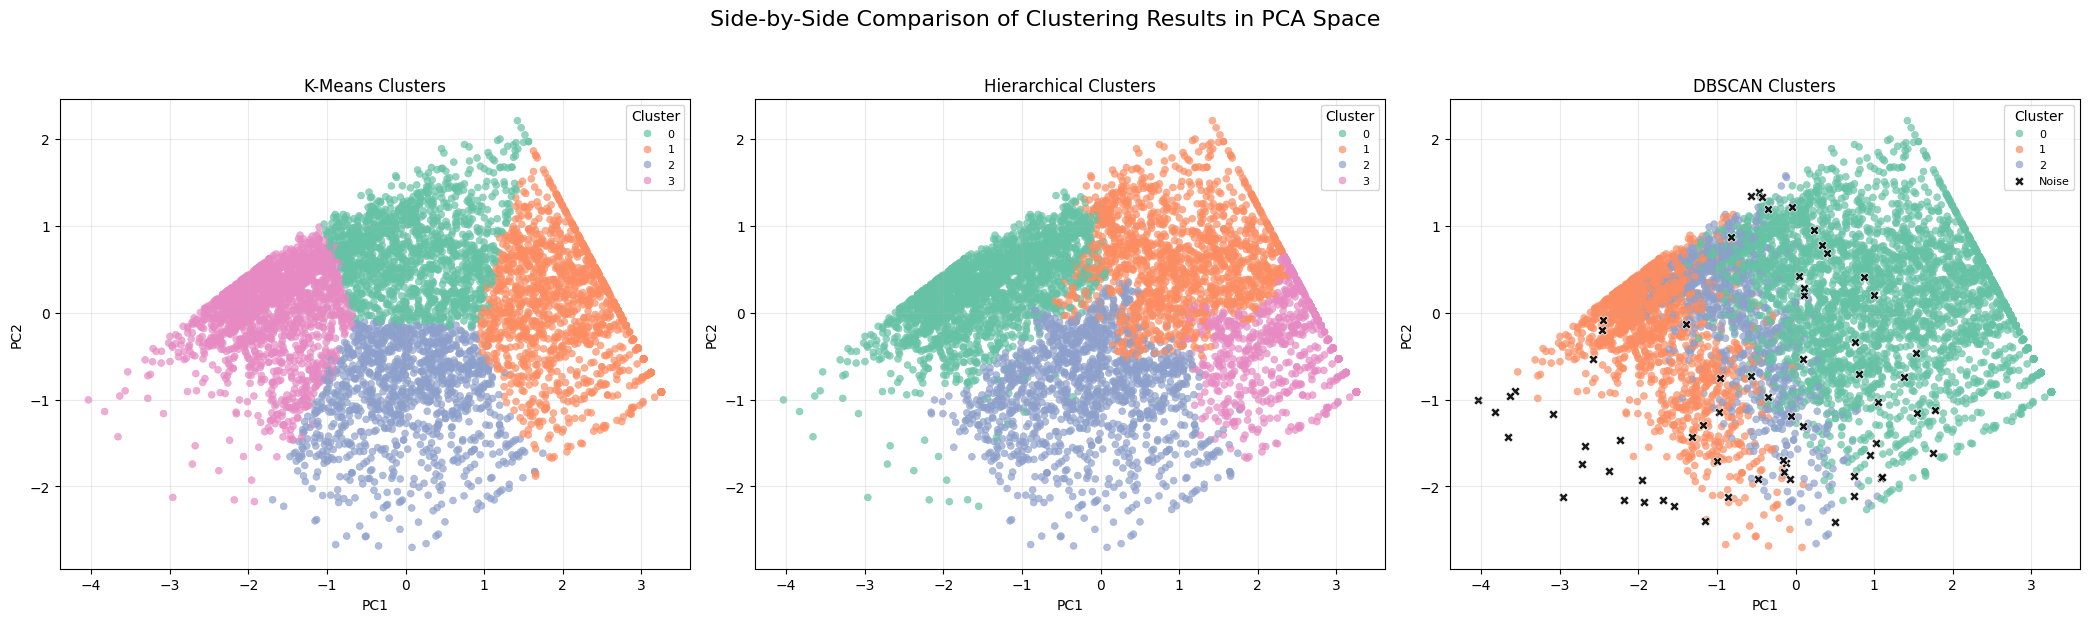

In [31]:
# Plot K-Means, Hierarchical, and DBSCAN results side-by-side in PCA space for direct visual comparison
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

plot_specs = [
    {
        'axis': axes[0],
        'data': pca_cluster_df,
        'label_col': 'Cluster',
        'title': 'K-Means Clusters',
        'noise': False
    },
    {
        'axis': axes[1],
        'data': pca_hierarchical_df,
        'label_col': 'Hierarchical_Cluster',
        'title': 'Hierarchical Clusters',
        'noise': False
    },
    {
        'axis': axes[2],
        'data': pca_dbscan_df,
        'label_col': 'DBSCAN_Cluster',
        'title': 'DBSCAN Clusters',
        'noise': True
    }
]

for spec in plot_specs:
    axis_vals = spec['axis']
    plot_df = spec['data']
    label_col = spec['label_col']
    if spec['noise']:
        non_noise_df = plot_df[plot_df[label_col] != -1]
        noise_df = plot_df[plot_df[label_col] == -1]
        sns.scatterplot(data=non_noise_df, x='PC1', y='PC2', hue=label_col, palette='Set2', s=25, alpha=0.7, edgecolor=None, ax=axis_vals, legend=True)
        sns.scatterplot(data=noise_df, x='PC1', y='PC2', color='black', marker='X', s=45, alpha=0.9, ax=axis_vals, label='Noise')
    else:
        sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue=label_col, palette='Set2', s=25, alpha=0.7, edgecolor=None, ax=axis_vals, legend=True)
    axis_vals.set_title(spec['title'])
    axis_vals.set_xlabel('PC1')
    axis_vals.set_ylabel('PC2')
    axis_vals.grid(alpha=0.25)
    axis_vals.legend(title='Cluster', loc='best', fontsize=8)

plt.suptitle('Side-by-Side Comparison of Clustering Results in PCA Space', fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

In [32]:
# Display a concise markdown analysis comparing all three clustering approaches
best_sil_algo = comparison_df.loc[comparison_df['Silhouette Score'].idxmax(), 'Algorithm']
best_db_algo = comparison_df.loc[comparison_df['Davies-Bouldin Index'].idxmin(), 'Algorithm']
best_ch_algo = comparison_df.loc[comparison_df['Calinski-Harabasz Index'].idxmax(), 'Algorithm']

analysis_text = """
### Comparative Clustering Analysis

#### Best-performing algorithm by metric

**Silhouette Score** was highest for **" + best_sil_algo + "**, meaning it produced the strongest average separation between customers and their nearest alternative clusters. Higher silhouette values are better because they indicate customers are closer to their own cluster than to neighboring clusters.

**Davies-Bouldin Index** was lowest for **" + best_db_algo + "**, which is preferred because lower values indicate clusters are more compact and better separated.

**Calinski-Harabasz Index** was highest for **" + best_ch_algo + "**, meaning it had the strongest ratio of between-cluster dispersion to within-cluster dispersion.

Overall, **K-Means performed best across all three internal metrics**, so it is the strongest quantitative choice for this RFM dataset.

#### Strengths and weaknesses for this RFM dataset

**K-Means** works well here because the preprocessed RFM features were log-transformed, scaled, and fairly compact in PCA space. Its main strength is producing clear, balanced, easy-to-explain marketing segments. Its weakness is that it assumes roughly spherical clusters and forces every customer into a segment.

**Hierarchical clustering** is useful because the dendrogram gives an intuitive view of customer similarity and possible cut points. It produced segments similar to K-Means, which supports the stability of the segmentation. Its weakness is that it was slightly weaker on all internal metrics and can be computationally heavier on larger datasets.

**DBSCAN** is helpful because it identifies noise points instead of forcing every customer into a cluster. In this case, it flagged unusual customers as noise, which could support anomaly detection. Its weakness is that it did not form broad marketing segments as cleanly as K-Means or hierarchical clustering.

#### Why DBSCAN struggled more here

DBSCAN depends heavily on local density. If the customer data has gradually changing density, overlapping groups, or relatively uniform regions after scaling, DBSCAN can either merge groups together or split them into many small clusters. It also becomes harder to choose a single `eps` value when different parts of the dataset have different densities.

Even though RFM only has three scaled dimensions here, DBSCAN can struggle more generally as dimensionality increases because distances become less informative. Points start to look similarly far apart, which weakens the meaning of a fixed neighborhood radius.

#### Effect of PCA on cluster separation

PCA helped visualization a lot. The first two components retained about **94.68%** of the variance, so the 2D plots are a faithful view of most of the scaled RFM structure. The PCA scatter plots made it easier to see that K-Means and hierarchical clustering form broad, interpretable regions, while DBSCAN mainly separates dense areas and flags a small number of noise points.

#### Recommended algorithm for marketing segmentation

For marketing segmentation, I would recommend **K-Means with 4 clusters**. It had the best internal validation scores, produced balanced customer groups, and gave business-friendly RFM profiles such as high-value loyal customers, recent lower-value customers, cooling customers, and inactive low-value customers.

DBSCAN is still useful as a secondary method for identifying unusual or outlier customers, but it is less suitable as the main segmentation model for this dataset.
"""

display(Markdown(analysis_text))


### Comparative Clustering Analysis

#### Best-performing algorithm by metric

**Silhouette Score** was highest for **" + best_sil_algo + "**, meaning it produced the strongest average separation between customers and their nearest alternative clusters. Higher silhouette values are better because they indicate customers are closer to their own cluster than to neighboring clusters.

**Davies-Bouldin Index** was lowest for **" + best_db_algo + "**, which is preferred because lower values indicate clusters are more compact and better separated.

**Calinski-Harabasz Index** was highest for **" + best_ch_algo + "**, meaning it had the strongest ratio of between-cluster dispersion to within-cluster dispersion.

Overall, **K-Means performed best across all three internal metrics**, so it is the strongest quantitative choice for this RFM dataset.

#### Strengths and weaknesses for this RFM dataset

**K-Means** works well here because the preprocessed RFM features were log-transformed, scaled, and fairly compact in PCA space. Its main strength is producing clear, balanced, easy-to-explain marketing segments. Its weakness is that it assumes roughly spherical clusters and forces every customer into a segment.

**Hierarchical clustering** is useful because the dendrogram gives an intuitive view of customer similarity and possible cut points. It produced segments similar to K-Means, which supports the stability of the segmentation. Its weakness is that it was slightly weaker on all internal metrics and can be computationally heavier on larger datasets.

**DBSCAN** is helpful because it identifies noise points instead of forcing every customer into a cluster. In this case, it flagged unusual customers as noise, which could support anomaly detection. Its weakness is that it did not form broad marketing segments as cleanly as K-Means or hierarchical clustering.

#### Why DBSCAN struggled more here

DBSCAN depends heavily on local density. If the customer data has gradually changing density, overlapping groups, or relatively uniform regions after scaling, DBSCAN can either merge groups together or split them into many small clusters. It also becomes harder to choose a single `eps` value when different parts of the dataset have different densities.

Even though RFM only has three scaled dimensions here, DBSCAN can struggle more generally as dimensionality increases because distances become less informative. Points start to look similarly far apart, which weakens the meaning of a fixed neighborhood radius.

#### Effect of PCA on cluster separation

PCA helped visualization a lot. The first two components retained about **94.68%** of the variance, so the 2D plots are a faithful view of most of the scaled RFM structure. The PCA scatter plots made it easier to see that K-Means and hierarchical clustering form broad, interpretable regions, while DBSCAN mainly separates dense areas and flags a small number of noise points.

#### Recommended algorithm for marketing segmentation

For marketing segmentation, I would recommend **K-Means with 4 clusters**. It had the best internal validation scores, produced balanced customer groups, and gave business-friendly RFM profiles such as high-value loyal customers, recent lower-value customers, cooling customers, and inactive low-value customers.

DBSCAN is still useful as a secondary method for identifying unusual or outlier customers, but it is less suitable as the main segmentation model for this dataset.


**Comparative analysis completed**\
I built and displayed the comparison table, plotted the three clustering outputs side-by-side in PCA space, and added a written analysis in markdown.\

**Summary table**\
Algorithm	n_clusters	Silhouette Score	Davies-Bouldin Index	Calinski-Harabasz Index	Notes
K-Means	4	0.3842	0.9138	5679.1224	Best overall metric performance; compact and interpretable RFM segments.
Hierarchical - Ward	4	0.3295	1.0070	4705.7582	Interpretable hierarchy; slightly weaker separation than K-Means.
DBSCAN	3	0.1867	1.6478	2976.1910	Detected noise customers; weaker broad segmentation performance.\
**Key takeaway**\
K-Means is the recommended algorithm for this RFM marketing segmentation task.

It performed best on all three internal metrics:

Silhouette Score was highest for K-Means, meaning it had the strongest average separation between customers and neighboring clusters.

Davies-Bouldin Index was lowest for K-Means, which means its clusters were more compact and better separated.

Calinski-Harabasz Index was highest for K-Means, showing the strongest ratio of between-cluster separation to within-cluster variation.\

**Practical interpretation**\
K-Means is the most useful model here because it produced clean, balanced, and business-friendly RFM segments. These are easy to explain in a marketing context, such as high-value loyal customers, recent low-to-mid value customers, cooling customers, and inactive low-value customers.

Hierarchical clustering was still useful because the dendrogram supported a similar 4-cluster structure. That gives confidence that the customer segmentation pattern is not just an artifact of K-Means. However, its validation scores were slightly weaker.

DBSCAN was useful for a different reason. It identified noise customers, which K-Means and hierarchical clustering do not do. That makes DBSCAN helpful for spotting unusual customer behavior or possible outliers. But it struggled to produce broad marketing-ready segments.\

**Why DBSCAN struggled here**\
DBSCAN depends on density. If customer density changes gradually across the RFM space, or if groups overlap, a single eps value may not separate the data cleanly.

Even though this RFM dataset only has three scaled features, DBSCAN can struggle more generally when data becomes higher-dimensional because distances become less meaningful. This makes it harder for DBSCAN to decide what counts as a dense neighborhood.\

**How PCA helped**\
PCA made the cluster structure much easier to visualize. Since the first two components explained about 94.68% of the variance, the 2D PCA plots preserved most of the important RFM structure.

The side-by-side PCA plots showed that K-Means and hierarchical clustering created clearer broad regions, while DBSCAN mostly separated density regions and marked a small set of customers as noise.\

**Recommendation**\
For the final capstone model, I would use:

python


KMeans(n_clusters=4, init='k-means++', random_state=42)
It gives the strongest metrics and the most practical segmentation for marketing actions.

DBSCAN can be included as a supporting analysis for noise or anomaly detection, but not as the main customer segmentation model.